In [1]:
%matplotlib inline

In [2]:
from utils import load_pickle
# nn = load_pickle('pickles/nn_results_all_24880.pkl')
# eqs = load_pickle('pickles/pysr_results_all_24880_11003.pkl')
# pure_sr = load_pickle('pickles/pure_sr_results_all_72420.pkl')
# pure_sr2 = load_pickle('pickles/pysr_results_all_28114_41564.pkl')
# petit = load_pickle('pickles/petit_results_all.pkl')

# mse_nn = load_pickle('pickles/nn_results_all_12318.pkl')
# mse_eqs = load_pickle('pickles/pysr_results_all_12318_93102.pkl')
# pure_sr_mse = load_pickle('pickles/pure_sr_results_all_83941.pkl')
# pure_sr2_mse = load_pickle('pickles/pysr_results_all_28114_93890.pkl')

In [1]:
from calc_rmse import official_calculations

/home/sca63/.conda/envs/planet_eqs/lib/python3.7/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  "torch was imported before juliacall. This may cause a segfault. "


Detected Jupyter notebook. Loading juliacall extension. Set `PYSR_AUTOLOAD_EXTENSIONS=no` to disable.


In [2]:
metrics = official_calculations()

petit
[test  ] Unstable RMSE=3.1291 Full RMSE=2.6956 Acc=0.3118  FPR (positive=unstable) =0.0059  FNR=0.9275 LL=-26.1537 Full LL=-26.5215
[random] Unstable RMSE=3.0037 Full RMSE=1.9810 Acc=0.5831  FPR (positive=unstable) =0.0001  FNR=0.9585 LL=-14.1610 Full LL=-14.9639
[train ] Unstable RMSE=3.1140 Full RMSE=2.6821 Acc=0.3089  FPR (positive=unstable) =0.0051  FNR=0.9315 LL=-26.0714 Full LL=-26.4410
[val   ] Unstable RMSE=3.1220 Full RMSE=2.6949 Acc=0.3092  FPR (positive=unstable) =0.0045  FNR=0.9271 LL=-26.1764 Full LL=-26.5411
nn
[test  ] Unstable RMSE=1.1196 Full RMSE=1.0731 Acc=0.8748  FPR (positive=unstable) =0.2756  FNR=0.0725 LL=-1.6414 Full LL=-2.0001
[random] Unstable RMSE=1.2595 Full RMSE=0.9750 Acc=0.8373  FPR (positive=unstable) =0.2085  FNR=0.1033 LL=-0.9118 Full LL=-1.7079
[train ] Unstable RMSE=1.0554 Full RMSE=1.0015 Acc=0.8787  FPR (positive=unstable) =0.2687  FNR=0.0696 LL=-1.5245 Full LL=-1.8862
[val   ] Unstable RMSE=1.1033 Full RMSE=1.0476 Acc=0.8714  FPR (positive=

In [14]:
period_ratio_official = load_pickle('pickles/period_ratio_official_metrics.pkl')

In [15]:
import pandas as pd

model_name_map = {
    'nn': 'Neural network',
    'pysr': 'Distilled equations',
    'pure_sr': 'Pure SR',
    'pure_sr2': 'Pure SR 2',
    'petit': 'Petit+2020',
}
period_ratio_name_map = {
    'NN     ': 'Neural network',
    'Ours    ': 'Distilled equations',
    'Pure SR': 'Pure SR',
    'Pure SR 2': 'Pure SR 2',
    'Petit  ': 'Petit+2020',
}

splits = ['test', 'random']
metrics_to_keep = ['rmse', 'acc', 'fpr', 'fnr']
rows = {}

for model_key, display_name in model_name_map.items():
    rows[display_name] = {
        (metric, split): metrics[model_key][split][metric]
        for split in splits
        for metric in metrics_to_keep
    }

result_table = pd.DataFrame.from_dict(rows, orient='index')
result_table.columns = pd.MultiIndex.from_tuples(result_table.columns, names=['metric', 'split'])

for raw_name, display_name in period_ratio_name_map.items():
    grid_metrics = period_ratio_official[raw_name]
    result_table.loc[display_name, ('rmse', 'grid')] = grid_metrics['unstable_rmse']
    result_table.loc[display_name, ('acc', 'grid')] = grid_metrics['acc']
    result_table.loc[display_name, ('fpr', 'grid')] = grid_metrics['fpr']
    result_table.loc[display_name, ('fnr', 'grid')] = grid_metrics['fnr']

split_order = ['test', 'random', 'grid']
metric_order = ['rmse', 'acc', 'fpr', 'fnr']
ordered_columns = [
    (metric, split)
    for metric in metric_order
    for split in split_order
    if (metric, split) in result_table.columns
]
result_table = result_table.reindex(columns=pd.MultiIndex.from_tuples(ordered_columns, names=['metric', 'split']))

result_table.style.format('{:.3f}').set_caption('Official results across resonant, random, and period-ratio grid datasets')



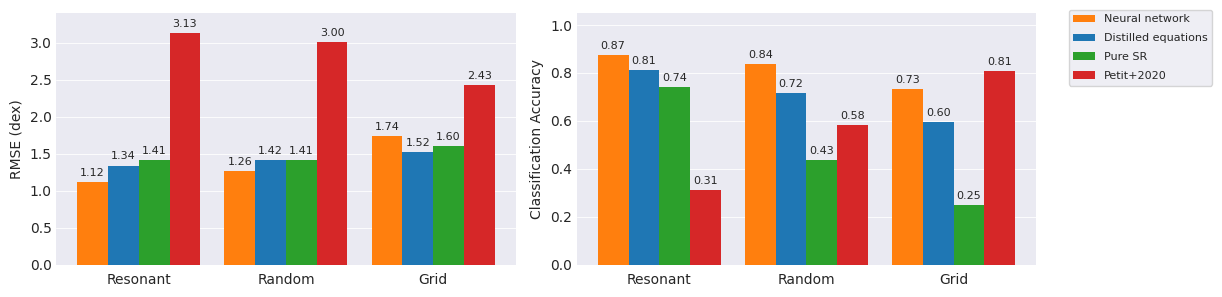

In [ ]:
from matplotlib import pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator

plt.style.use('seaborn-darkgrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # plt.rcParams['font.family'] = 'serif'


methods = ['Neural network', 'Distilled equations', 'Pure SR', 'Petit+2020']
rmse_datasets = ['Resonant', 'Random', 'Grid']
acc_datasets = ['Resonant', 'Random', 'Grid']

def series_for(method, metric):
    split_lookup = [('test', 'Resonant'), ('random', 'Random'), ('grid', 'Grid')]
    return [result_table.loc[method, (metric, split)] for split, _ in split_lookup]

rmse_dict = {method: series_for(method, 'rmse') for method in methods}
acc_dict = {method: series_for(method, 'acc') for method in methods}

cmap = plt.get_cmap('tab10')
method_colors = dict(zip(methods, [cmap(i) for i in [1, 0, 2, 3]]))

scale = 0.8
fig, (ax_rmse, ax_acc) = plt.subplots(1, 2, figsize=(scale * 15, scale * 4))
fig.subplots_adjust(right=0.88, wspace=0.35)

bw = 0.23
x_spacing = 1.1
legend_handles = []

x_rmse = np.arange(len(rmse_datasets)) * x_spacing
for i, method in enumerate(methods):
    offset = (i - 1.5) * bw
    vals = rmse_dict[method]
    ax_rmse.bar(x_rmse + offset, vals, width=bw, color=method_colors[method])
    legend_handles.append(plt.Rectangle((0, 0), 1, 1, fc=method_colors[method], label=method))
    for j, value in enumerate(vals):
        ax_rmse.annotate(f'{value:.2f}', xy=(x_rmse[j] + offset, value), xytext=(0, 3),
                         textcoords='offset points', ha='center', va='bottom', fontsize=8)

ax_rmse.grid(True, axis='y', linewidth=0.6)
ax_rmse.grid(False, axis='x')
ax_rmse.set_xticks(x_rmse)
ax_rmse.set_xticklabels(rmse_datasets, fontsize=10)
ax_rmse.set_ylabel('RMSE (dex)')
ax_rmse.set_ylim(0, 3.4)
ax_rmse.yaxis.set_major_locator(MultipleLocator(0.5))
ax_rmse.tick_params(axis='x', pad=6)

x_acc = np.arange(len(acc_datasets)) * x_spacing
for i, method in enumerate(methods):
    offset = (i - 1.5) * bw
    vals = acc_dict[method]
    ax_acc.bar(x_acc + offset, vals, width=bw, color=method_colors[method])
    for j, value in enumerate(vals):
        ax_acc.annotate(f'{value:.2f}', xy=(x_acc[j] + offset, value), xytext=(0, 3),
                        textcoords='offset points', ha='center', va='bottom', fontsize=8)

ax_acc.grid(True, axis='y', linewidth=0.6)
ax_acc.grid(False, axis='x')
ax_acc.set_xticks(x_acc)
ax_acc.set_xticklabels(acc_datasets, fontsize=10)
ax_acc.set_ylabel('Classification Accuracy')
ax_acc.set_ylim(0, 1.05)
ax_acc.yaxis.set_major_locator(MultipleLocator(0.2))
ax_acc.tick_params(axis='x', pad=6)

fig.legend(handles=legend_handles,
           loc='upper left', bbox_to_anchor=(0.89, 0.93),
           bbox_transform=fig.transFigure,
           frameon=True, fontsize=8,
           labelspacing=0.8)
plt.tight_layout(rect=[0, 0, 0.88, 0.95])
plt.savefig('graphics/rmse_acc_plot.svg', bbox_inches='tight')
plt.show()